### Scenario, a beverage analytics that delivery reports to restaurants

### Structured output in JSON
- Example: Llama responses might be input to a dashboard
- Plain text responses won't work
- We need structured outputs

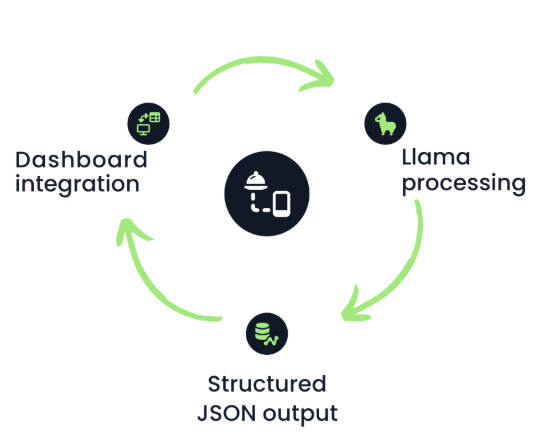


### JSON responses with chat completion

In [1]:
from llama_cpp import Llama

In [2]:
llm = Llama(model_path='models/Meta-Llama-3.1-8B-Instruct-Q5_K_S.gguf')

llama_model_loader: loaded meta data with 33 key-value pairs and 292 tensors from models/Meta-Llama-3.1-8B-Instruct-Q5_K_S.gguf (version GGUF V3 (latest))
llama_model_loader: Dumping metadata keys/values. Note: KV overrides do not apply in this output.
llama_model_loader: - kv   0:                       general.architecture str              = llama
llama_model_loader: - kv   1:                               general.type str              = model
llama_model_loader: - kv   2:                               general.name str              = Meta Llama 3.1 8B Instruct
llama_model_loader: - kv   3:                           general.finetune str              = Instruct
llama_model_loader: - kv   4:                           general.basename str              = Meta-Llama-3.1
llama_model_loader: - kv   5:                         general.size_label str              = 8B
llama_model_loader: - kv   6:                            general.license str              = llama3.1
llama_model_loader: - kv   7

In [3]:
response_format = {'type': 'json_object'}

message_list = [{
    'role': 'system',
    'content': 'You are a food industry market analyst. You analyze sales data and generate structured JSON reports of top-selling beverages.'
},
    {
        'role': 'user',
        'content': 'Provide a structured report on the top-selling beverages this year.'
    }]

In [4]:
output = llm.create_chat_completion(
    messages=message_list,
    response_format=response_format
)

llama_perf_context_print:        load time =    5031.76 ms
llama_perf_context_print: prompt eval time =    5031.38 ms /    69 tokens (   72.92 ms per token,    13.71 tokens per second)
llama_perf_context_print:        eval time =   94327.06 ms /   442 runs   (  213.41 ms per token,     4.69 tokens per second)
llama_perf_context_print:       total time =  111618.59 ms /   511 tokens
llama_perf_context_print:    graphs reused =        440


- Response **format** specified as **JSON**
- Llama generates structured response, no free-flowing text

In [5]:
print(output['choices'][0]['message']['content'])

{ "report": {
  "title": "Top-Selling Beverages Report for 2024",
  "period": "January 1 - June 30, 2024",
  "data_source": "National Sales Data",
  "top_beverages": [
    {
      "rank": 1,
      "name": "Pepsi",
      "category": "Cola",
      "sales_volume": 23456789,
      "sales_value": 123456789,
      "growth_rate": 3.5
    },
    {
      "rank": 2,
      "name": "Coca-Cola",
      "category": "Cola",
      "sales_volume": 12345678,
      "sales_value": 987654321,
      "growth_rate": 2.8
    },
    {
      "rank": 3,
      "name": "Mountain Dew",
      "category": "Energy Drink",
      "sales_volume": 87654321,
      "sales_value": 654321098,
      "growth_rate": 4.2
    },
    {
      "rank": 4,
      "name": "Red Bull",
      "category": "Energy Drink",
      "sales_volume": 76543210,
      "sales_value": 543210987,
      "growth_rate": 3.8
    },
    {
      "rank": 5,
      "name": "Sprite",
      "category": "Lemon-Lime Soda",
      "sales_volume": 65432109,
      "sales_v

## Defining a schema
- Can specify a **schema**: rules to define how the data should be formatted

In [18]:
response_format = {
    "type": "json_object",
    "schema": {
        "type": "object",
        "properties": {
            "products": {
                "type": "array",
                "items": {
                    "type": "object",
                    "properties": {
                        "Product Name": {"type": "string"},
                        "Category": {"type": "string"},
                        "Sales Growth": {"type": "number"}
                    },
                    "required": ["Product Name", "Category", "Sales Growth"],
                    "additionalProperties": False
                }
            }
        },
        "required": ["products"],
        "additionalProperties": False
    }
}

In [19]:
output = llm.create_chat_completion(
    messages=message_list,
    response_format=response_format
)

Llama.generate: 68 prefix-match hit, remaining 1 prompt tokens to eval
llama_perf_context_print:        load time =    5031.76 ms
llama_perf_context_print: prompt eval time =       0.00 ms /     1 tokens (    0.00 ms per token,      inf tokens per second)
llama_perf_context_print:        eval time =   58967.86 ms /   264 runs   (  223.36 ms per token,     4.48 tokens per second)
llama_perf_context_print:       total time =   64735.40 ms /   265 tokens
llama_perf_context_print:    graphs reused =        262


In [20]:
print(output['choices'][0]['message']['content'])

{ "products": [ { "Product Name": "Pepsi", "Category": "Soft Drinks", "Sales Growth": 3.5 }, { "Product Name": "Coca-Cola", "Category": "Soft Drinks", "Sales Growth": 2.8 }, { "Product Name": "Red Bull", "Category": "Energy Drinks", "Sales Growth": 12.1 }, { "Product Name": "Monster Energy", "Category": "Energy Drinks", "Sales Growth": 10.5 }, { "Product Name": "Diet Coke", "Category": "Soft Drinks", "Sales Growth": 2.2 }, { "Product Name": "Fanta", "Category": "Soft Drinks", "Sales Growth": 4.8 }, { "Product Name": "Sprite", "Category": "Soft Drinks", "Sales Growth": 3.8 }, { "Product Name": "Gatorade", "Category": "Sports Drinks", "Sales Growth": 8.5 }, { "Product Name": "Powerade", "Category": "Sports Drinks", "Sales Growth": 6.2 }, { "Product Name": "Vitaminwater", "Category": "Enhanced Water", "Sales Growth": 15.6 } ] }
